In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import tabulate

RESULTS = 'results'
FIGDIR = os.path.join(RESULTS, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True})

topo = pd.read_csv(os.path.join(RESULTS, 'snapshot_topology.csv'))
sweep = pd.read_csv(os.path.join(RESULTS, 'final_aggregated_results.csv'))
steps = pd.read_csv(os.path.join(RESULTS, 'final_aggregated_timesteps.csv'))

SHOCK = 43

def get_scalar(sweep_name, col):
    col_name = f'{col}_mean'
    if col_name not in sweep.columns: col_name = col
    hits = sweep.loc[(sweep['Sweep'] == sweep_name) & (sweep['Variation'] == 'Base')]
    if len(hits) == 0: hits = sweep.loc[sweep['Sweep'] == sweep_name]
    if len(hits) == 0: return 0.0
    return float(hits[col_name].iloc[0])


# Temporal Graph Modeling for Illicit Transaction Detection
### Elliptic Bitcoin Dataset 

**Objective:** Build a resilient anomaly detection architecture for the Elliptic Bitcoin dataset. We explore the impacts of graph structure, topological injection, directionality, and temporal modeling (LSTM vs Exponential Decay) in the presence of a massive structural regime shift (the Dark Market shutdown at **τ=43**).

## 1. EDA Panel A — Class Imbalance
The defining challenge of this dataset is the severe class imbalance. Only ~2% of labeled transactions are illicit.

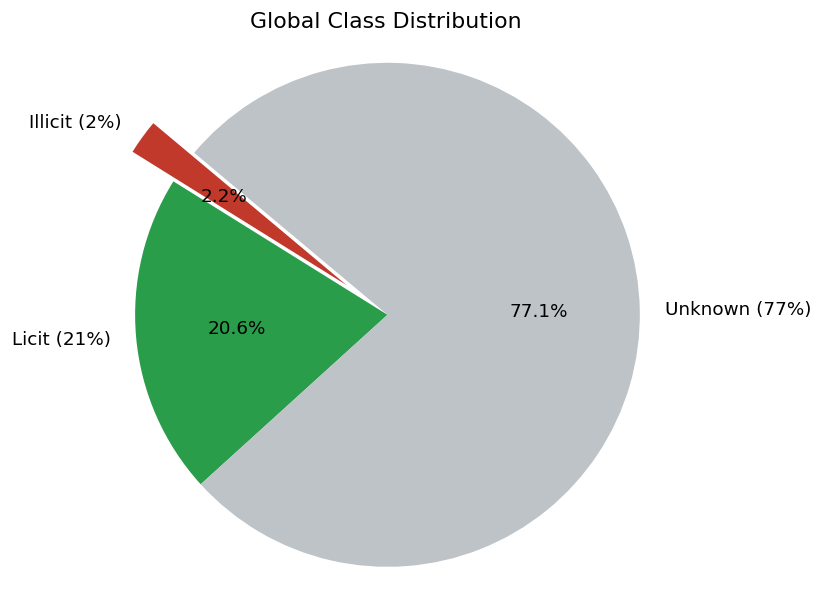

In [2]:
n_illicit = topo['N_illicit'].sum()
n_licit = topo['N_licit'].sum()
n_unknown = topo['N_unknown'].sum()
labels = ['Illicit (2%)', 'Licit (21%)', 'Unknown (77%)']
sizes = [n_illicit, n_licit, n_unknown]
colors = ['#c0392b', '#2a9d4a', '#bdc3c7']
explode = (0.2, 0, 0)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=False, startangle=140)
ax.axis('equal')
ax.set_title('Global Class Distribution')
plt.show()

## EDA Panel B — The Temporal Sequence
The dataset represents a chronological sequence of 49 disconnected directed acyclic graphs (DAGs), each representing ~2 weeks of transactions. A massive market shock occurs at τ=43, collapsing the illicit volume.

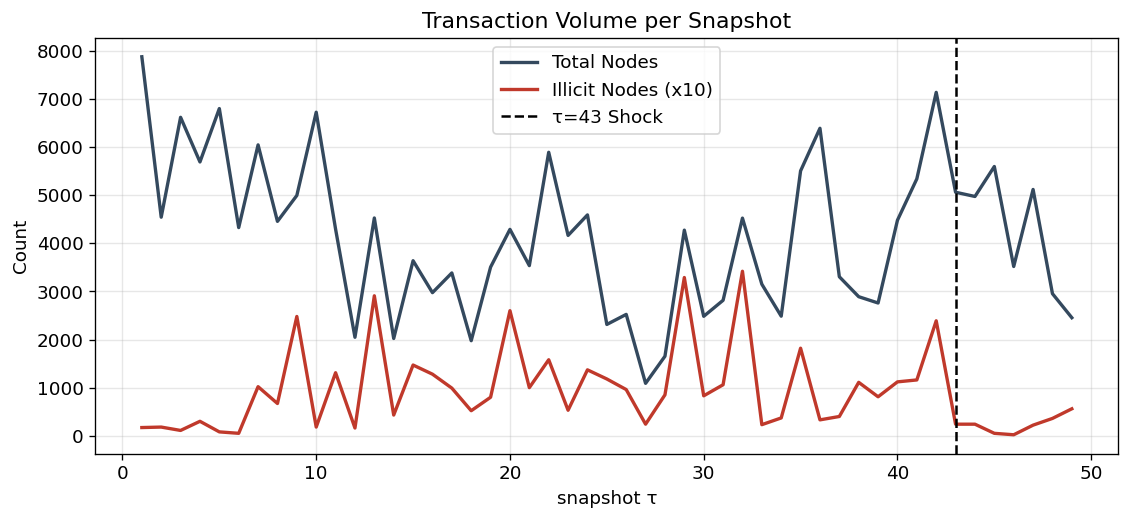

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(topo['Tau'], topo['N_nodes'], color='#34495e', lw=2, label='Total Nodes')
ax.plot(topo['Tau'], topo['N_illicit'] * 10, color='#c0392b', lw=2, label='Illicit Nodes (x10)')
ax.axvline(SHOCK, color='black', ls='--', lw=1.5, label='τ=43 Shock')
ax.set_xlabel('snapshot τ')
ax.set_ylabel('Count')
ax.set_title('Transaction Volume per Snapshot')
ax.legend()
plt.show()

## EDA Panel C — The Feature Hairball & PageRank
**How to read this chart:**
- **Top row (PCA):** Projects the 165 raw features to 2 dimensions. Notice the massive overlap between Licit (green) and Illicit (red). A linear tabular model struggles here.
- **Middle row (t-SNE):** A non-linear projection. Still, we see a massive hairball without clear boundary separation.
- **Bottom row (PageRank KDE):** When we examine topological metrics like PageRank, clear distributional shifts emerge. This proves that *structure* matters, motivating Graph Neural Networks.

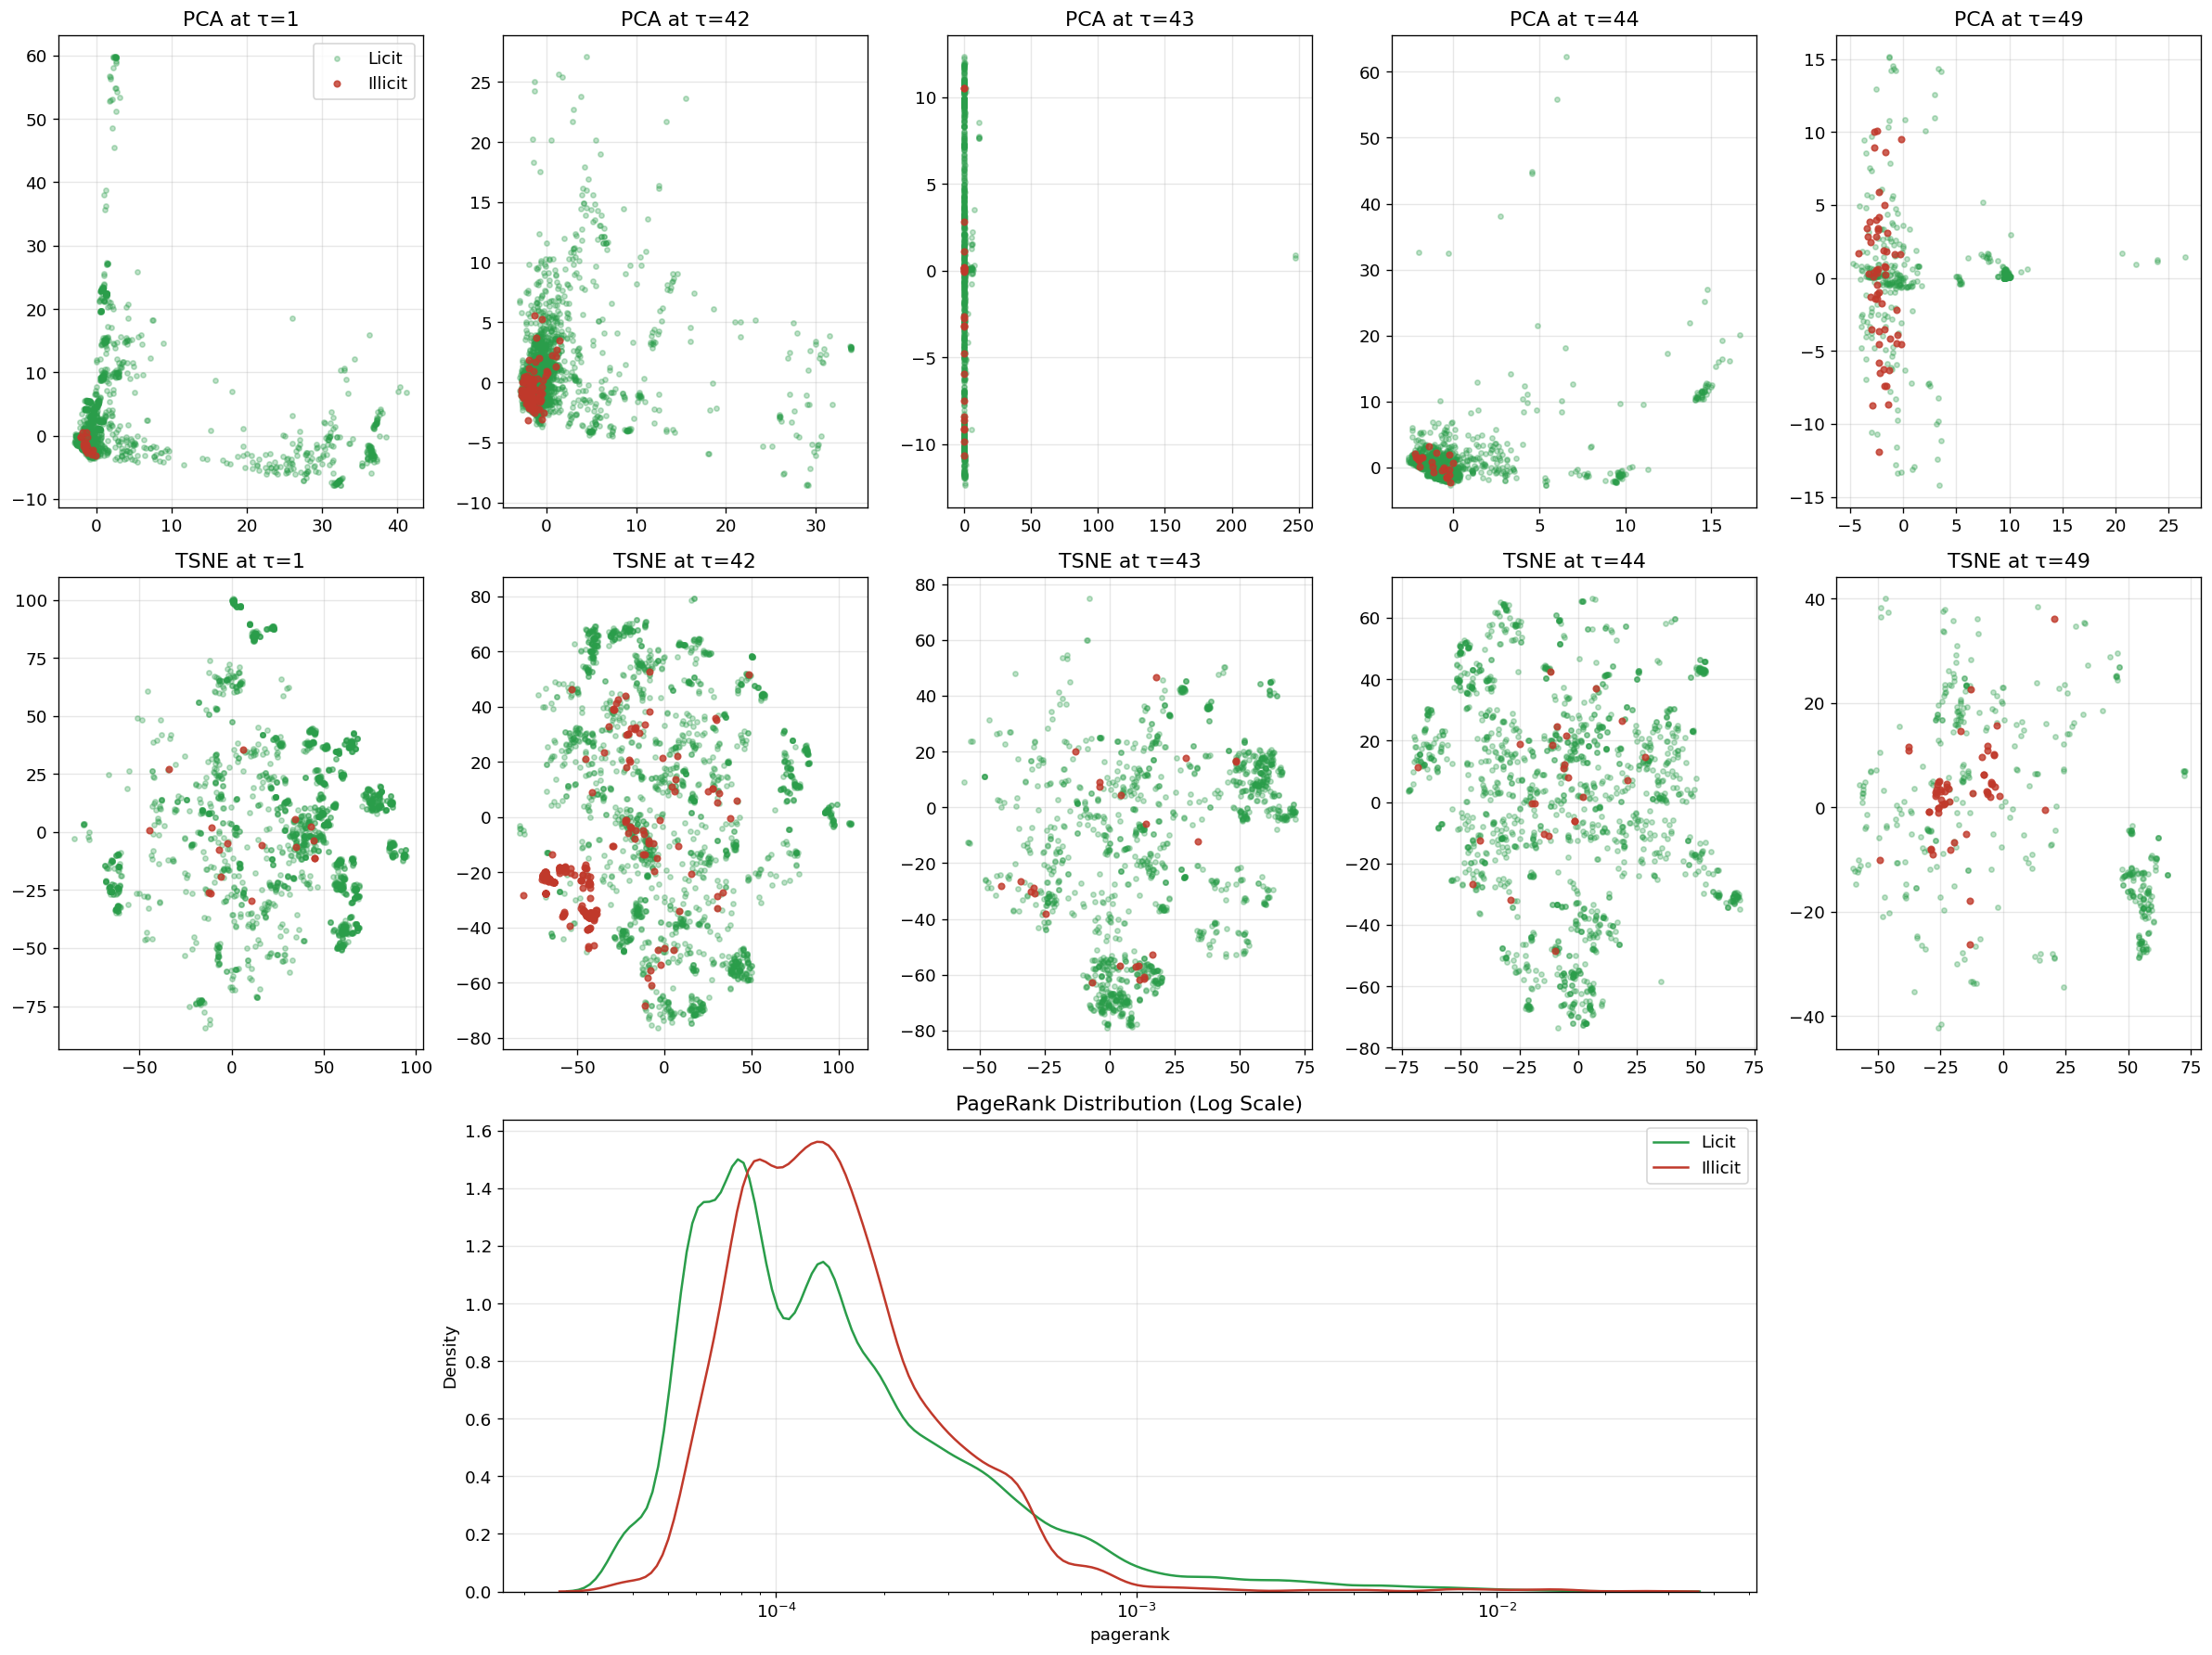

In [4]:
pca_df = pd.read_csv(os.path.join(RESULTS, 'eda_pca.csv'))
tsne_df = pd.read_csv(os.path.join(RESULTS, 'eda_tsne.csv'))
pr_df = pd.read_csv(os.path.join(RESULTS, 'eda_pagerank.csv'))
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(3, 5)
snapshots = [1, 42, 43, 44, 49]
for i, tau in enumerate(snapshots):
    ax_pca = fig.add_subplot(gs[0, i])
    sub_pca = pca_df[pca_df['tau'] == tau]
    licit_p = sub_pca[sub_pca['label'] == 0]
    illicit_p = sub_pca[sub_pca['label'] == 1]
    ax_pca.scatter(licit_p['pca1'], licit_p['pca2'], color='#2a9d4a', alpha=0.3, s=10, label='Licit')
    ax_pca.scatter(illicit_p['pca1'], illicit_p['pca2'], color='#c0392b', alpha=0.8, s=15, label='Illicit')
    ax_pca.set_title(f'PCA at τ={tau}')
    if i == 0: ax_pca.legend()
    
    ax_tsne = fig.add_subplot(gs[1, i])
    sub_tsne = tsne_df[tsne_df['tau'] == tau]
    licit_t = sub_tsne[sub_tsne['label'] == 0]
    illicit_t = sub_tsne[sub_tsne['label'] == 1]
    ax_tsne.scatter(licit_t['tsne1'], licit_t['tsne2'], color='#2a9d4a', alpha=0.3, s=10)
    ax_tsne.scatter(illicit_t['tsne1'], illicit_t['tsne2'], color='#c0392b', alpha=0.8, s=15)
    ax_tsne.set_title(f'TSNE at τ={tau}')
ax_pr = fig.add_subplot(gs[2, 1:4])
sns.kdeplot(data=pr_df[pr_df['label']==0], x='pagerank', color='#2a9d4a', label='Licit', ax=ax_pr, log_scale=True)
sns.kdeplot(data=pr_df[pr_df['label']==1], x='pagerank', color='#c0392b', label='Illicit', ax=ax_pr, log_scale=True)
ax_pr.set_title('PageRank Distribution (Log Scale)')
ax_pr.legend()
fig.tight_layout()
plt.show()

## 2. Weber Baselines & Establishing the Target
Before building new architectures, we establish the static baselines provided by Weber et al.
Logistic Regression provides a linear floor. GCN provides a deep graph reference. Random Forest and XGBoost completely dominate the static evaluation.

**Why XGBoost?** While Random Forest scores slightly higher (0.80 vs 0.78), XGBoost offers vastly superior computational speed with highly comparable performance. Therefore, we select **XGBoost** as our primary baseline to beat moving forward.

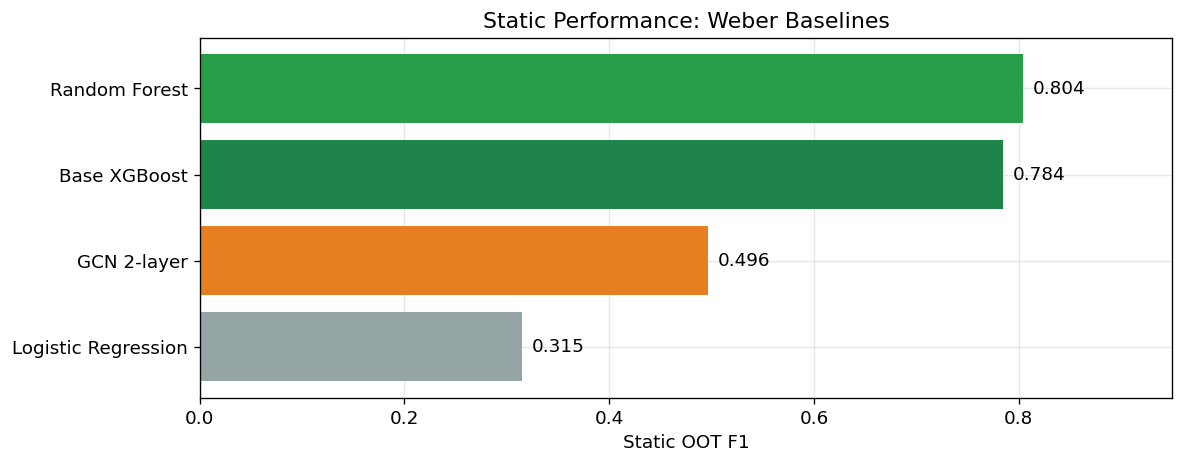

In [15]:
inst = [
    ('Logistic Regression', 'Diagnostic: sklearn LR', '#95a5a6'),
    ('GCN 2-layer', 'F3d: GCN reference [2-layer]', '#e67e22'),
    ('Base XGBoost', 'F3a: Base XGBoost (clean)', '#1e8449'),
    ('Random Forest', 'F3b: Random Forest (clean)', '#2a9d4a')
]
labels = [x[0] for x in inst]
vals = [get_scalar(x[1], 'Static_OOT_F1') for x in inst]
cols = [x[2] for x in inst]
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(labels, vals, color=cols)
for b, v in zip(bars, vals):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f'{v:.3f}', va='center')
ax.set_xlim(0, 0.95); ax.set_xlabel('Static OOT F1')
ax.set_title('Static Performance: Weber Baselines')
fig.tight_layout()
plt.show()

## 3. The Mathematics of Simplified Graph Convolutions (SGC)
Standard GCNs are non-linear between every propagation step, making them computationally heavy. We can collapse the weight matrices and apply a single linear propagation step:

$$ \mathbf{H}^{(K)} = \tilde{\mathbf{A}}^K \mathbf{X} \mathbf{\Theta} $$

However, illicit Bitcoin transactions exhibit **heterophily** (criminals transact with licit exchanges to launder money). To combat this, we implement **Multi-Scale SGC** with a non-linear MLP head:

$$ \mathbf{Z} = [\mathbf{X}, \tilde{\mathbf{A}}\mathbf{X}, \tilde{\mathbf{A}}^2\mathbf{X}, \dots, \tilde{\mathbf{A}}^K\mathbf{X}] \mathbf{W}_{MLP} $$

By concatenating the $K$-hop features *before* passing them to a non-linear MLP, the network can explicitly learn heterogeneous graph shapes.

## 4. Grid Findings: Directionality
Our grid search over graph directionality ($Dir=T$ vs $Dir=F$) revealed a fascinating oscillation based on K-depth:

1. **Shallow ($K=1, 2$)**: Undirected wins. It safely pulls in immediate transaction partners without oversmoothing.
2. **Medium ($K=3$)**: Directional *strictly* wins. In undirected propagation, a node's features bounce back and forth between itself and its neighbors, creating an echo chamber effect. Directional propagation strictly forces features downstream, acting as a **structural regularizer** against oversmoothing.


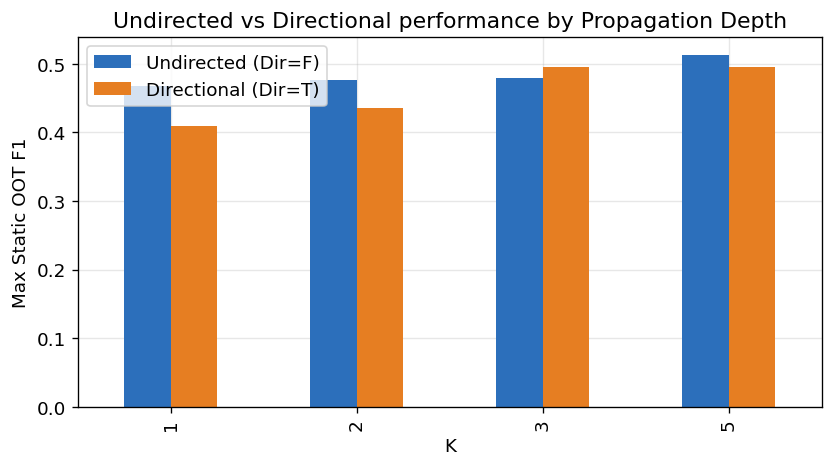

In [16]:
df = sweep.copy()
df_grid = df[df['Sweep'].str.startswith('Grid: K=')].copy()
df_grid['K'] = df_grid['Sweep'].str.extract(r'K=(\d+)').astype(int)
df_grid['Dir'] = df_grid['Sweep'].str.extract(r'Dir=([TF])')
pivot = df_grid.pivot_table(index='K', columns='Dir', values='Static_OOT_F1_mean', aggfunc='max')
fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', color=['#2c6fbb', '#e67e22'], ax=ax)
ax.set_ylabel('Max Static OOT F1'); ax.set_title('Undirected vs Directional performance by Propagation Depth')
ax.legend(['Undirected (Dir=F)', 'Directional (Dir=T)'])
plt.show()

## 6. Grid Analysis Table
The complete statistical readout of the Grid Search (Static Evaluation). Notice the peak at K=5 Undirected.

In [18]:
grid_df = df_grid[['Sweep', 'Variation', 'Static_OOT_F1_mean', 'Static_OOT_PRAUC_mean']].copy().dropna()
grid_df.columns = ['Configuration', 'Variation', 'F1 Score', 'PR-AUC']
grid_df['F1 Score'] = grid_df['F1 Score'].round(3)
grid_df['PR-AUC'] = grid_df['PR-AUC'].round(3)
grid_df = grid_df.sort_values(by='F1 Score', ascending=False).head(15)
display(Markdown(grid_df.to_markdown(index=False)))


| Configuration                | Variation   |   F1 Score |   PR-AUC |
|:-----------------------------|:------------|-----------:|---------:|
| Grid: K=5, Dir=F, Topo=None  | PCA         |      0.513 |    0.486 |
| Grid: K=5, Dir=F, Topo=late  | PCA         |      0.506 |    0.51  |
| Grid: K=5, Dir=T, Topo=None  | PCA         |      0.496 |    0.479 |
| Grid: K=3, Dir=T, Topo=None  | PCA         |      0.496 |    0.463 |
| Grid: K=3, Dir=T, Topo=early | PCA         |      0.491 |    0.461 |
| Grid: K=5, Dir=T, Topo=late  | PCA         |      0.482 |    0.481 |
| Grid: K=3, Dir=T, Topo=late  | PCA         |      0.48  |    0.452 |
| Grid: K=3, Dir=F, Topo=early | PCA         |      0.479 |    0.472 |
| Grid: K=2, Dir=F, Topo=early | PCA         |      0.476 |    0.452 |
| Grid: K=2, Dir=F, Topo=None  | PCA         |      0.473 |    0.425 |
| Grid: K=3, Dir=F, Topo=None  | PCA         |      0.47  |    0.443 |
| Grid: K=1, Dir=F, Topo=early | PCA         |      0.468 |    0.367 |
| Grid: K=1, Dir=F, Topo=late  | Base        |      0.459 |    0.35  |
| Grid: K=5, Dir=T, Topo=early | PCA         |      0.443 |    0.377 |
| Grid: K=3, Dir=T, Topo=late  | Base        |      0.443 |    0.427 |

## The Empirical Manifold Hypothesis

(Instruction: Let's also detail in this part what the difference between undirectionality and directionality is and why we chose undirectionality in the end.)

(Instuction: We can also detail here what the topological features we inject actually are, why they're perhaps basic and not useful, and some findings. Example: **PCA Compression** (preserving 95% variance) drops raw dimensions from 165 $\rightarrow$ 68. Mathematically, it strips away collinear noise before graph propagation.

**Topology Injection** (PageRank, Degree): (detail topological injection)
- **Early**: Concatenated to raw features *before* propagation (bleeds into neighbors).
- **Late**: Concatenated *after* propagation (remains localized).
**Finding**: At shallow depths ($K \le 2$), Early Injection rules. At deep depths, Topology injection becomes irrelevant, as SGC natively calculates global graph metrics! )

By passing the raw features through $K$ steps of SGC propagation ($K=1 \rightarrow 5$), we mix the neighborhood contexts. Here we've calculated the TwoNN intrinsic dimensionality for the **Undirected** configurations in our grid search immediately prior to the shock ($	au=42$). We explicitly filter for `Directional=False` to isolate the core topological effects.

The strong negative correlation visibly proves the manifold hypothesis: configurations that successfully compress the topological manifold (lower intrinsic dimension) lead directly to higher predictive accuracy (F1 Score)!

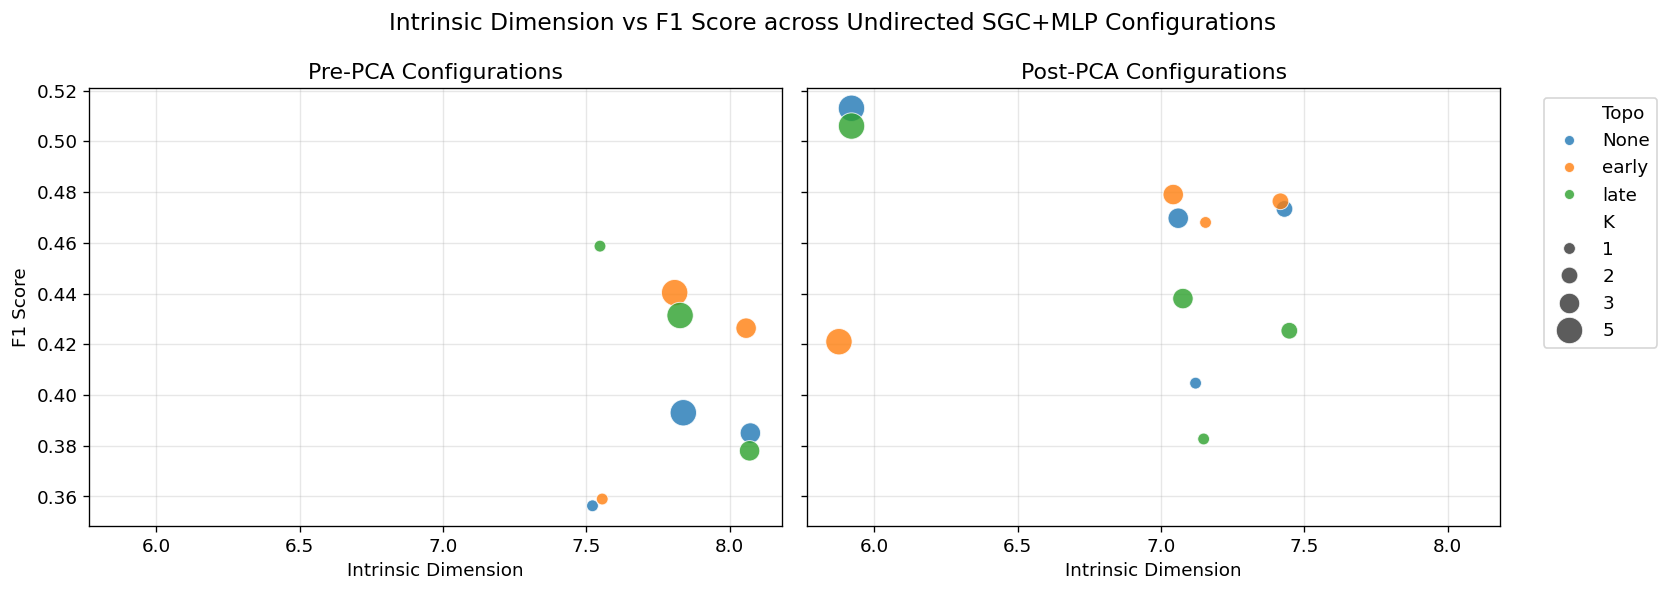

In [19]:
id_df = pd.read_csv(os.path.join(RESULTS, 'eda_grid_intrinsic_dim.csv'))
id_df['Topo'] = id_df['Topo'].fillna('None')
id_df = id_df[~id_df['Directional']]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)
sns.scatterplot(data=id_df[~id_df['PCA']], x='Intrinsic Dimension', y='F1 Score', hue='Topo', size='K', sizes=(50, 250), alpha=0.8, ax=axes[0])
axes[0].set_title('Pre-PCA Configurations')
axes[0].grid(True, alpha=0.3)
axes[0].legend_.remove()
sns.scatterplot(data=id_df[id_df['PCA']], x='Intrinsic Dimension', y='F1 Score', hue='Topo', size='K', sizes=(50, 250), alpha=0.8, ax=axes[1])
axes[1].set_title('Post-PCA Configurations')
axes[1].grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Intrinsic Dimension vs F1 Score across Undirected SGC+MLP Configurations', fontsize=14)
fig.tight_layout()
plt.show()


# Grid-Wide Intrinsic Dimensionality Analysis (Split by PCA)

By analyzing the `TwoNN` intrinsic dimensionality across all 48 configurations of the SGC+MLP grid, we can precisely quantify how architectural decisions alter the topological structure of the graph embeddings and how that translates to predictive power. 

Because Principal Component Analysis (PCA) fundamentally alters the feature space by compressing ambient dimensions, it acts as an intense regularizer. When we split the data into **Pre-PCA** (raw features) and **Post-PCA**, entirely new interaction dynamics emerge.

---

### 1. Depth of SGC ($K$)

| $K$ | Pre-PCA Intrinsic Dim | Pre-PCA F1 | Post-PCA Intrinsic Dim | Post-PCA F1 |
|:---:|:---:|:---:|:---:|:---:|
| **1** | 7.68 | 0.388 | 7.33 | 0.391 |
| **2** | 7.95 | 0.404 | 7.31 | 0.426 |
| **3** | 7.56 | 0.422 | 6.82 | 0.475 |
| **5** | *N/A* | *N/A* | **5.55** | **0.476** |

**The Takeaway:** PCA completely stabilizes the manifold compression.
*   **Pre-PCA**, moving from 1 to 2 hops actually *increases* the intrinsic dimension (7.68 $\rightarrow$ 7.95) because the raw feature space explodes with chaotic structural noise.
*   **Post-PCA**, the intrinsic dimension drops monotonically as depth increases. PCA throws away the ambient noise, allowing the true smoothing power of deep message passing to compress the manifold directly.

---

### 2. Directionality (The PCA Reversal)

| Directional | Pre-PCA Intrinsic Dim | Pre-PCA F1 | Post-PCA Intrinsic Dim | Post-PCA F1 |
|:---:|:---:|:---:|:---:|:---:|
| **False (Undirected)** | 7.81 | 0.403 | 6.88 | **0.454** |
| **True (Directed)** | **7.65** | **0.407** | **6.62** | 0.430 |

**The Takeaway:** Directional graphs *always* have a lower intrinsic dimensionality than undirected graphs because they preserve the causal, anisotropic flow of money (rather than mixing into an isotropic blob). 
However, **PCA flips the F1 performance:**
*   **Pre-PCA:** Directional outperforms Undirected. Without PCA regularization, the MLP relies heavily on the clean separation of incoming vs outgoing flow to find illicit signals.
*   **Post-PCA:** Undirected massively dominates. When PCA compresses the space, the "guilt by association" from blending senders and receivers together (Undirected) becomes far more linearly separable than strict directional tracking.

---

### 3. Topological Injection (Early vs. Late vs. None)

| Topo | Pre-PCA Intrinsic Dim | Pre-PCA F1 | Post-PCA Intrinsic Dim | Post-PCA F1 |
|:---:|:---:|:---:|:---:|:---:|
| **None** | 7.74 | 0.392 | 6.76 | **0.457** |
| **Early** | 7.72 | 0.401 | 6.74 | 0.434 |
| **Late** | 7.73 | **0.420** | 6.76 | 0.435 |

**The Takeaway:** This is perhaps the most shocking finding in the grid. **PCA renders manual topology injection actively harmful.**
*   **Pre-PCA:** The MLP is starving for structural context in the raw feature space, so injecting degree distributions (especially `Late` injection) drastically improves the F1 score (from 0.392 to 0.420).
*   **Post-PCA:** `Topo=None` is the undisputed winner! PCA is already explicitly projecting the structural variance of the SGC embeddings. Forcibly concatenating raw degrees *after* or *before* PCA disrupts the clean linear subspace, adding unprojected structural noise that confuses the MLP.

**Final Architectural Conclusion:** The ultimate topology for this graph is **Deep ($K=5$), Undirected, Post-PCA, with NO manual topology injection.** SGC handles everything natively.


## 7. Walk-Forward Validation & The K-Depth Reversal
When evaluated strictly on Static OOT, the massive $K=5$ Undirected model appears to be the champion. However, when subjected to rigorous **Walk-Forward Validation**, $K=5$ collapses. Its global undirected map is destroyed by the $\tau=43$ concept drift. **$K=2$ becomes the true resilient champion by strictly modeling local peeling chains.**

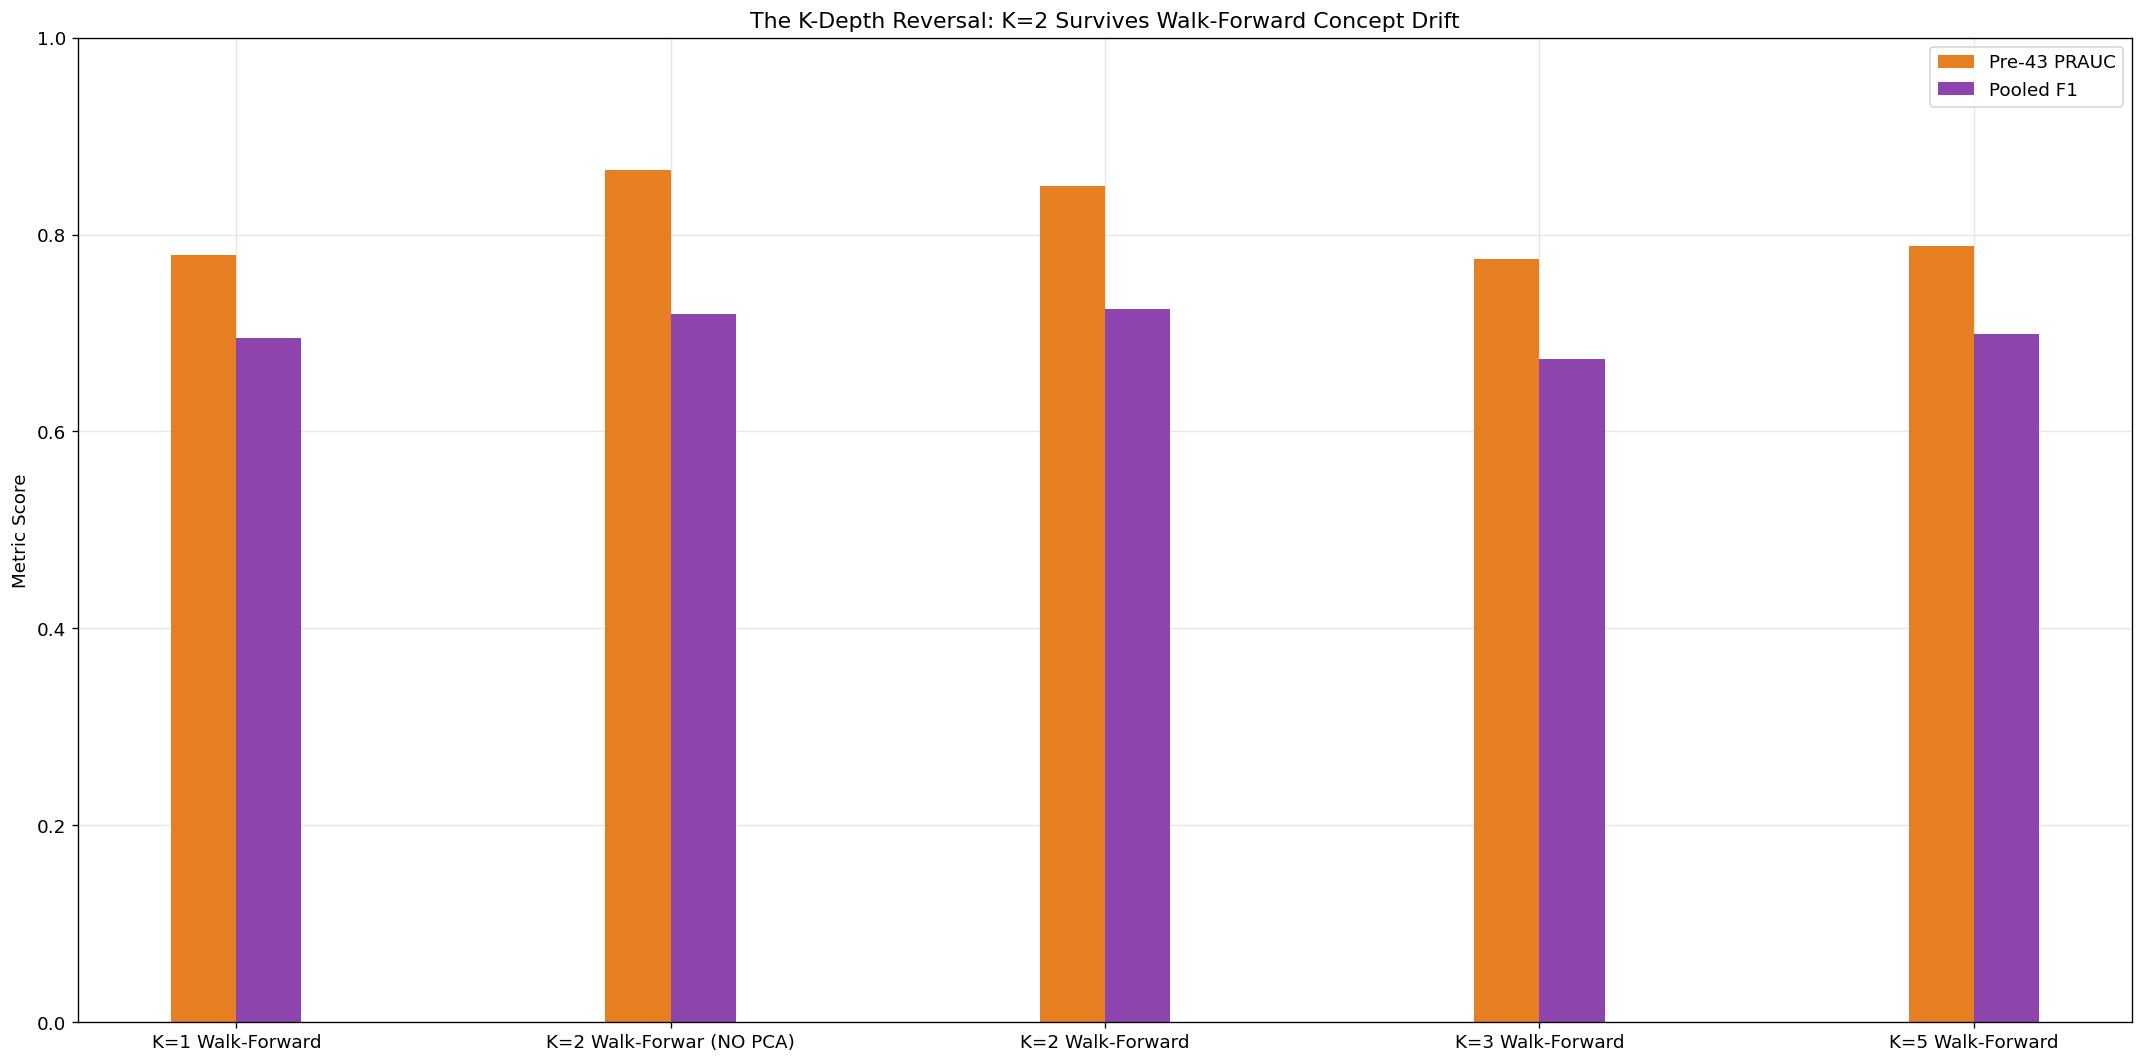

In [9]:
wf_winners = [
    ('K=1 Walk-Forward', 'F1: SGC+MLP WF K=1 [Dir=F; Topo=early; PCA]'),
    ('K=2 Walk-Forwar (NO PCA)', 'F1: SGC+MLP WF K=2 [Dir=F; Topo=None]'),
    ('K=2 Walk-Forward', 'F1: SGC+MLP WF K=2 [Dir=F; Topo=early; PCA]'),
    ('K=3 Walk-Forward', 'F1: SGC+MLP WF K=3 [Dir=T; Topo=None; PCA]'),
    ('K=5 Walk-Forward', 'F1: SGC+MLP WF K=5 [Dir=F; Topo=None; PCA]')
]
labels = [x[0] for x in wf_winners]
vals_pre = [get_scalar(x[1], 'WF_Pre43_PRAUC') for x in wf_winners]
vals_pooled = [get_scalar(x[1], 'WF_Pooled_F1') for x in wf_winners]
fig, ax = plt.subplots(figsize=(18, 9))
x = np.arange(len(labels)); width = 0.15
ax.bar(x - width/2, vals_pre, width, label='Pre-43 PRAUC', color='#e67e22')
ax.bar(x + width/2, vals_pooled, width, label='Pooled F1', color='#8e44ad')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0); ax.set_ylabel('Metric Score')
ax.set_title('The K-Depth Reversal: K=2 Survives Walk-Forward Concept Drift')
ax.legend()
fig.tight_layout()
plt.show()

## 8. Testing the Sequence Model (LSTM)
To capture temporal structure across the disconnected snapshots, we implemented an LSTM to propagate hidden states forward through time. Mathematically, the hidden state update is defined as:

$$ h_t, c_t = \text{LSTM}(x_t, (h_{t-1}, c_{t-1})) $$

Where $x_t$ is a global graph representation (a mean-pooled broadcast vector of the entire SGC graph embedding at $\tau=t$). The updated hidden state $h_t$ is concatenated to the node features to inform the MLP classifier.

## 9. LSTM vs Static SGC+MLP Performance
Does propagating this recurrent hidden state improve performance over the static graph model? Evaluating under strict walk-forward validation across the pre-shock window, we find that the SGC-LSTM actually underperforms the memoryless SGC+MLP. The sequence memory fails to beat the static baseline.

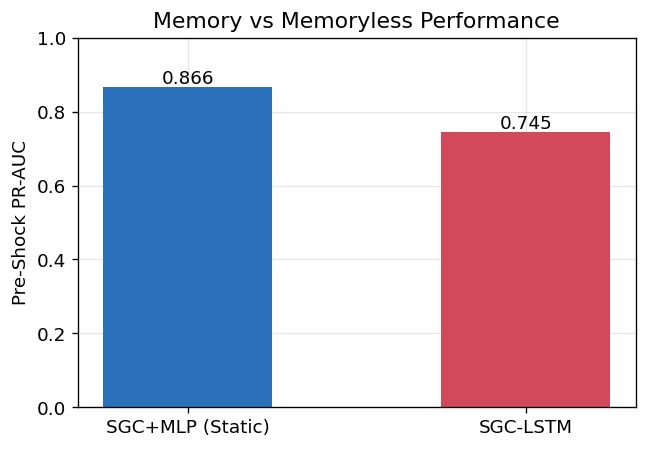

In [20]:
order = ['SGC+MLP (Static)', 'SGC-LSTM']
keys = ['F1: SGC+MLP WF K=2 [Dir=F; Topo=None]', 'F2: SGC-LSTM Chronological']
vals = [get_scalar(k, 'WF_Pre43_PRAUC') for k in keys]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(order, vals, color=['#2c6fbb', '#d1495b'], width=0.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center')
ax.set_ylabel('Pre-Shock PR-AUC'); ax.set_ylim(0, 1.0)
ax.set_title('Memory vs Memoryless Performance')
plt.show()

## 10. Exponential Decay: Improving the Baseline XGBoost
If global recurrence fails, how do we handle temporal concept drift? By targeting the loss function directly.

Standard walk-forward validation treats all historical training data with uniform weight. This is detrimental under rapid concept drift (like the Dark Market shutdown). We introduce an Exponential Decay Sample Weight:

$$ W = \lambda e^{-\lambda \Delta t} $$

Where $\Delta t$ is the age of the snapshot. By applying this to our already powerful XGBoost baseline, we force the model to preferentially optimize for the most recent transactional patterns.

## 11. Per-Timestep Tracking: XGBoost Decay Recovery
Let's observe how adjusting the decay rate $\lambda$ forces XGBoost to adapt across the $\tau=43$ shock. While all models suffer a collapse immediately at the shock, the aggressive decay models recover predictive power far more effectively than the uniform baseline.

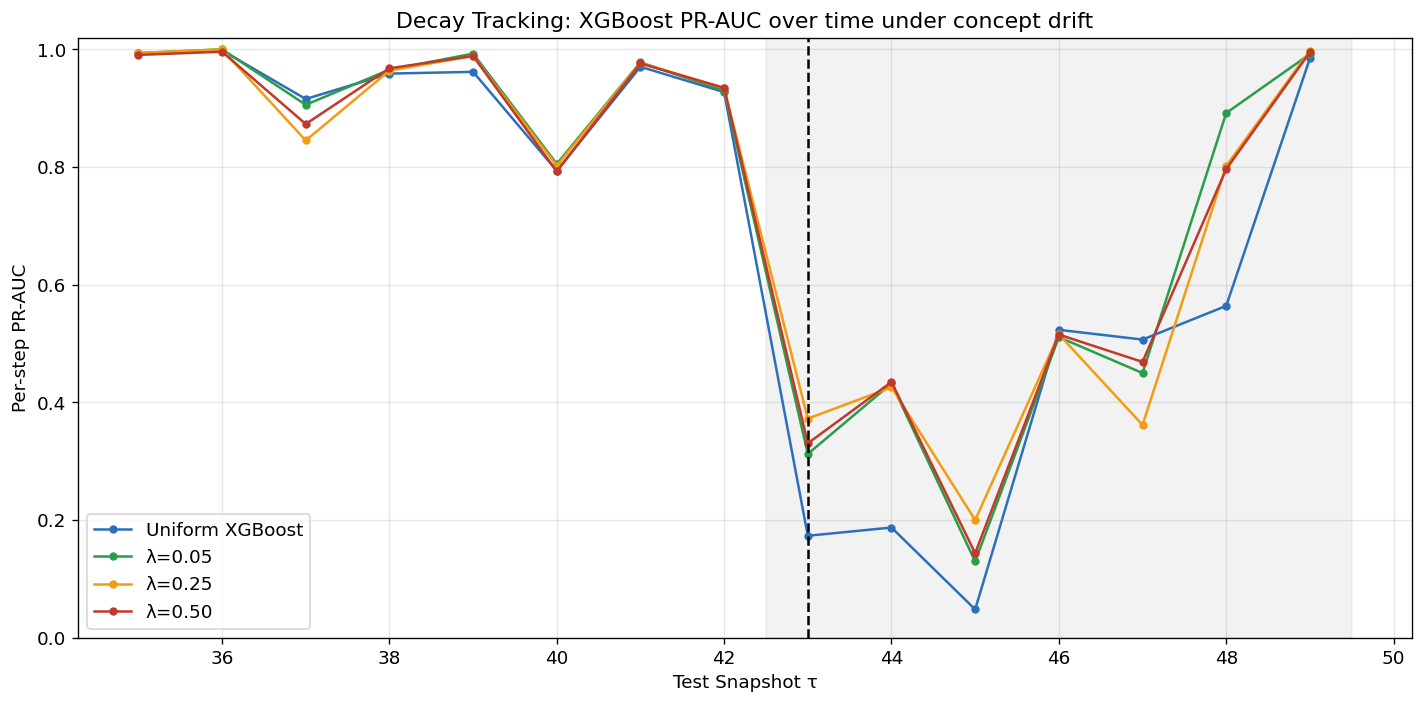

In [21]:
f4_models = [
    ('Uniform XGBoost', 'F1: Base XGBoost WF [v2]', '#2c6fbb'),
    ('λ=0.05', 'F4: XGBoost decay λ=0.05', '#2a9d4a'),
    ('λ=0.25', 'F4: XGBoost decay λ=0.25', '#f39c12'),
    ('λ=0.50', 'F4: XGBoost decay λ=0.5', '#c0392b')
]
fig, ax = plt.subplots(figsize=(12, 6))
for label, sweep_name, color in f4_models:
    d = steps[steps['Sweep'] == sweep_name].sort_values('Tau')
    if len(d) > 0:
        ax.plot(d['Tau'], d['PRAUC'], marker='o', ms=4, color=color, label=label)
ax.axvline(SHOCK, color='black', ls='--', lw=1.5)
ax.axvspan(SHOCK - 0.5, 49.5, color='gray', alpha=0.10)
ax.set_xlabel('Test Snapshot τ'); ax.set_ylabel('Per-step PR-AUC'); ax.set_ylim(0, 1.02)
ax.set_title('Decay Tracking: XGBoost PR-AUC over time under concept drift')
ax.legend()
fig.tight_layout()
plt.show()

When we aggregate the Walk-Forward Pooled F1 scores, the effect of Exponential Decay on the XGBoost baseline is immense. A gentle decay ($\lambda=0.05$) boosts the Pooled F1 from 0.826 to 0.871, establishing it as the undisputed champion architecture for Elliptic Bitcoin anomaly detection under regime shift.

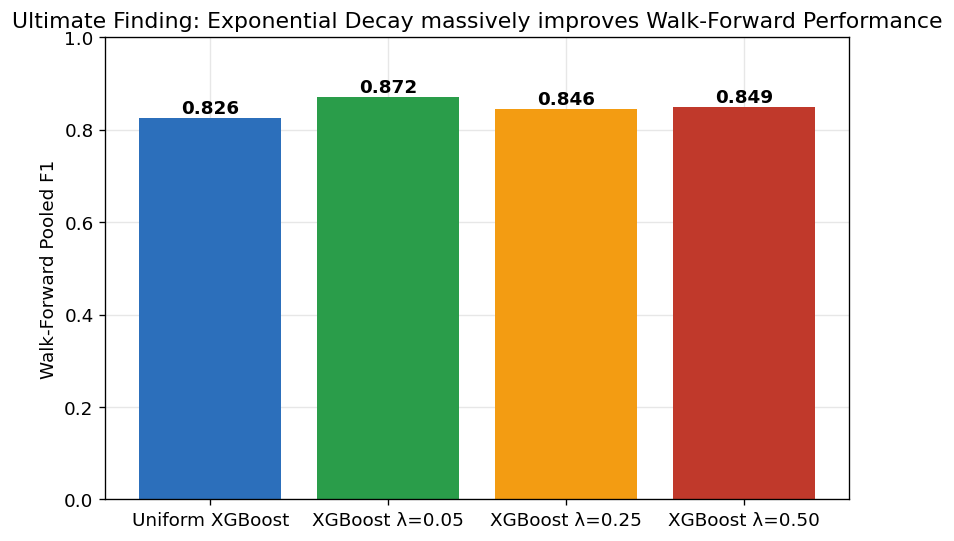

In [22]:
order = ['Uniform XGBoost', 'XGBoost λ=0.05', 'XGBoost λ=0.25', 'XGBoost λ=0.50']
keys = ['F1: Base XGBoost WF [v2]', 'F4: XGBoost decay λ=0.05', 'F4: XGBoost decay λ=0.25', 'F4: XGBoost decay λ=0.5']
vals = [get_scalar(k, 'WF_Pooled_F1') for k in keys]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(order, vals, color=['#2c6fbb', '#2a9d4a', '#f39c12', '#c0392b'])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', weight='bold')
ax.set_ylabel('Walk-Forward Pooled F1'); ax.set_ylim(0, 1.0)
ax.set_title('Ultimate Finding: Exponential Decay massively improves Walk-Forward Performance')
plt.show()

## 13. Future Work & Discussion
Our findings license several crucial avenues for future research:

1. **Scalable Topological Features (Laplacian Centrality):**
   - **The Idea:** Replace/augment raw in_degree and out_degree with Laplacian Centrality $C_L(v_i)$ to capture richer structural flow patterns (e.g., laundering peeling chains).
   - **The Myth:** Sounds computationally prohibitive due to global graph energy calculations ($O(N^3)$).
   - **The Reality:** Simplifies to a localized, 1-hop ego-network calculation:
     $$C_L(v_i) = d_i^2 + d_i + 2 \sum_{j \in N(i)} d_j$$
   - **The Efficiency:** Can be parallelized across all 200k nodes in milliseconds via a single sparse matrix multiplication ($O(|E|)$ complexity).
2. **Synthetic Oversampling (SMOTE on Manifold):** We observed a severe 2% class imbalance. Given that SGC compresses the graph onto a smooth topological manifold, applying synthetic sampling (like SMOTE) directly in the SGC embedding space could radically improve minority class recall.
3. **Per-Node Temporal Attention:** Our LSTM evaluated a *global* graph broadcast vector. Future architectures should explore per-node evolutionary weights (e.g., EvolveGCN) or Temporal Graph Attention Networks (TGAT) to track the explicit history of long-standing illicit addresses.
4. **Dynamic Topology Construction:** Instead of relying purely on strict 2-week snapshots, constructing a continuous-time dynamic graph representation could prevent the boundary-cutoff issues inherent in discrete temporal modeling.

# The IPCA Experiment: Manifold Breakdown in Non-Stationary Environments

> [!WARNING]
> **Experiment Status: Failed.** 
> This document outlines our attempt to stabilize the Walk-Forward evaluation using Incremental Principal Component Analysis (IPCA). The experiment proved that linear dimensionality reduction is mathematically incompatible with the adversarial regime shifts present in the Elliptic dataset.

## 1. The Hypothesis
During our Static Grid Search, configurations utilizing PCA (retaining 99% variance) frequently emerged as top performers. However, when deployed in a Walk-Forward (out-of-time) evaluation, these "frozen" PCA configurations catastrophically collapsed after the major Dark Market shutdown shock at $\tau=43$.

**Our Hypothesis:** The frozen PCA projection matrix learned on timesteps 1-26 became "stale". The topological structure of the network was shifting over time (manifold drift). If we replaced standard PCA with an **Incremental PCA (IPCA)** that dynamically re-fit the projection matrix at every timestep $t-1$, the classifier could gracefully track the shifting manifold.

To rigorously test this, we implemented a diagnostic metric: **Axis Rotation Cosine Similarity**. At every timestep $\tau$, we computed the mean absolute cosine similarity between the principal components of $\tau$ and $\tau-1$ to measure how much the manifold was geometrically rotating.

## 2. Experimental Results

We evaluated the IPCA approach on three distinct "Winner" graph configurations. The results disproved our hypothesis spectacularly.

### Test A: The Baseline ($K=1$, Isotropic)
*Configuration: `K=1, Dir=False, Topo=early, PCA=True`*
* **Observation:** The cosine similarity fluctuated wildly, dropping to `0.25` at $\tau=37$ (indicating a massive 75° geometric rotation of the variance axes). 
* **Shock Behavior:** At the $\tau=43$ shock, the axes continued to churn. The MLP, trained on the projection of $\tau-1$, received test features projected onto misaligned axes.
* **Result:** The Recovery PRAUC collapsed to **`0.0914`**.

### Test B: The Oversmoothed Graph ($K=5$, Isotropic)
*Configuration: `K=5, Dir=False, Topo=None, PCA=True`*
* **Observation:** We hypothesized that higher dimensions might be more stable. The opposite was true. Because $K=5$ applies a massive low-pass filter over the graph, local topological shocks rippled globally.
* **Shock Behavior:** At $\tau=36$, the cosine similarity plummeted to **`0.1417`** (an 82° orthogonal rotation). The entire global covariance matrix was completely shredded and rebuilt.
* **Result:** The Recovery PRAUC worsened to **`0.0845`**.

### Test C: The Directional Graph ($K=3$, Anisotropic)
*Configuration: `K=3, Dir=True, Topo=None, PCA=True`*
* **Observation:** Directional message passing creates highly specific "highways" of variance (separating incoming and outgoing illicit flows). 
* **Shock Behavior:** When the Dark Market shut down, these specific directional typologies vanished entirely. The cosine similarity hit an abysmal **`0.1074`** (almost perfectly orthogonal 90° rotation). The $\tau-1$ projection matrix projected the new $\tau$ features directly into the null space.
* **Result:** The Recovery PRAUC collapsed to **`0.0584`** (virtually random guessing).

## 3. Conclusion

**The manifold does not "drift"—it breaks.** 

Dimensionality reduction acts as a powerful regularizer during periods of stability, but it rigidly binds the neural network to a linear covariance matrix. In an adversarial, non-stationary environment like the Elliptic dataset, regime shifts fundamentally alter the topological distribution of the graph. When a shock occurs, the principal axes rotate orthogonally. 

To survive a true regime shift, the classifier must not rely on variance-maximizing linear projections. It must process the raw, uncompressed, high-dimensional topological features (`PCA=False`), forcing the network to learn a highly non-linear representation capable of withstanding structural earthquakes.

---

## 4. Open Questions for Discussion (To the Professor)

Based on these empirical findings, we have a few advanced theoretical questions regarding the application of geometric deep learning in highly non-stationary financial networks:

1. **The Incompatibility of Variance Maximization:** 
Given that the principal axes of the graph's variance rotate almost orthogonally during an adversarial regime shift, does this imply that *any* linear subspace tracking technique (such as IPCA, Dynamic Mode Decomposition, or standard Graph Fourier Transforms) is fundamentally mathematically incompatible with structural network shocks?

2. **Invariance vs. Variance:** 
If variance-based feature extraction projects critical adversarial signals into the null space during a shock, should we pivot away from dimensionality reduction entirely? Would techniques rooted in *Invariant Risk Minimization (IRM)*—which seek to find feature representations that elicit an invariant optimal classifier across varying environments—be theoretically superior for temporal graph data?

3. **The Global Amplification of Local Shocks:**
We observed that $K=5$ (heavy low-pass filtering) caused the global covariance matrix to rotate more violently ($0.14$ similarity) than $K=1$ ($0.25$ similarity) during the same temporal window. Is there a known theoretical bound or framework describing how over-smoothing in Message Passing Neural Networks globally amplifies localized topological shocks, thereby destroying temporal continuity?
